#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 7: Gatos y Perros  </center>

Con el resurgimiento de las redes convolucionales en 2012, entre otras cosas gracias a la viabilidad de entrenar con millones de imágenes, una serie de problemas considerados muy difíciles o inabordables hasta entonces debido a la necesidad de generar algoritmos muy específicos para cada tarea  pasaron a estar al alcance de cualquier desarrollador. Un ejemplo emblemático es el de distinguir entre imágenes de perros y gatos. Debido a la gran variabilidad intra clase de estos animales, es realmente dificil generar características que permitan separar bien las clases y probablemente el esfuerzo que conlleva generar características específicas, no esté justificado por la relevancia del problema. En este taller se verá el procedimiento para entrenar un clasificador a partir de un número no muy grande de imágenes, sin necesidad de diseñar características.

## Objetivos

 - Familiarizarse con la estructura *Dataset* de tensorflow 
 - Aprender a utilizar modelos de clasificación de imágenes preentrenados en *tensorflow* con imágenes de *Imagenet* 
 - Conocer las opciones para realizar *aumento de datos* y aplicárselo a las imágenes de perros y gatos
 - Realizar *transferencia de aprendizaje* del modelo preentrenado con *Imagenet* al problema de clasificar perros y gatos
 - Explicar en base a qué regiones de una imagen el clasificador toma la decisión 

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/TAA-fing/TAA-2026/blob/main/talleres/taller7_gatos_y_perros.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Ejecutar en Google Colab</a>
  </td>
</table>

In [1]:
import ctypes
import os
import site
from pathlib import Path

# En WSL/VS Code, TensorFlow puede no encontrar cuSOLVER automaticamente.
# Esta precarga debe ejecutarse antes de importar TensorFlow.
cusolver_path = (
    Path(site.getusersitepackages())
    / "nvidia"
    / "cusolver"
    / "lib"
    / "libcusolver.so.11"
)
if cusolver_path.exists():
    ctypes.CDLL(str(cusolver_path), mode=ctypes.RTLD_GLOBAL)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

I0000 00:00:1781094910.349190    4197 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


## Parte 0 - Utilización de GPU

El entrenamiento de redes convolucionales en general es más rápido cuando se utiliza GPU (Graphic Processor Unit). Correr la siguiente celda y verificar que se está utilizando una. Debería observar un mensaje similar al siguiente:

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

En caso de no observar dicho mensaje y estar trabajando en Colab, verifique que el entorno de ejecución es el correcto, vaya a:  
Entorno de ejecuccióón-->Cambiar tipo de entorno de ejecución-->GPU

### Adaptación de WSL para usar GPU local

In [2]:
gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    print("No se detecto GPU desde TensorFlow.")
else:
    print("GPUs detectadas por TensorFlow:")
    for gpu in gpus:
        print(f"- {gpu.name}")

    with tf.device("/GPU:0"):
        a = tf.random.normal((1024, 1024))
        b = tf.random.normal((1024, 1024))
        c = tf.matmul(a, b)

    print(f"Operacion de prueba ejecutada en: {c.device}")

GPUs detectadas por TensorFlow:
- /physical_device:GPU:0
Operacion de prueba ejecutada en: /job:localhost/replica:0/task:0/device:GPU:0


I0000 00:00:1781094913.155703    4197 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Parte 1 - Levantar los datos

Se trabajará con los datos disponibles en [Kaggle](https://www.kaggle.com/c/dogs-vs-cats/overview). En caso de estar trabajando en Colab seguir los siguientes pasos:

a) Installar el paquete *kaggle* para acceder a los datos 

In [3]:
# !pip install kaggle

b) Realizar la configuración necesaria para obtener datos desde la plataforma Kaggle.

### Configuración para trabajar en Colab

Ir a la página de la competencia y en la sección *data* aceptar los términos. Luego ejecutar la siguiente celda y pasarle el *token* de su usuario (ver comentario en celda).

In [4]:
# import warnings
# warnings.filterwarnings('ignore')
# from google.colab import files

# # El archivo solicitado es para habilitar la API de Kaggle en el entorno que está trabajando.
# # Este archivo se descarga entrando a su perfíl de Kaggle, en la sección API, presionando donde dice: Create New API Token

# uploaded = files.upload()

# for fn in uploaded.keys():
#   print('User uploaded file "{name}" with length {length} bytes'.format(
#       name=fn, length=len(uploaded[fn])))
  
# #Then move kaggle.json into the folder where the API expects to find it.
# !mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Una vez guardado el *token* se pueden descargar los datos.

In [5]:
# # celda para bajar los datos desde colab
# !kaggle competitions download -c dogs-vs-cats
# !unzip /content/dogs-vs-cats.zip
# !unzip /content/train.zip
# !unzip /content/test1.zip

### Configuración para trabajar local

En caso de estar trabajando localmente ejecutar la siguiente celda.

**Opción local para este repositorio.** 

In [6]:
from pathlib import Path
import zipfile

data_folder = Path("data") / "data_taller7"
train_zip_path = data_folder / "train.zip"
test_zip_path = data_folder / "test1.zip"
sample_submission_path = data_folder / "sampleSubmission.csv"

train_dir = data_folder / "train"
test_dir = data_folder / "test1"

required_files = [train_zip_path, test_zip_path, sample_submission_path]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    missing_text = ", ".join(str(path) for path in missing_files)
    raise FileNotFoundError(f"Faltan archivos esperados en data/data_taller7: {missing_text}")

for zip_path, output_dir in [(train_zip_path, train_dir), (test_zip_path, test_dir)]:
    if not output_dir.exists():
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(data_folder)

n_train_images = len(list(train_dir.glob("*.jpg")))
n_test_images = len(list(test_dir.glob("*.jpg")))

print(f"Carpeta de datos: {data_folder.resolve()}")
print(f"Imagenes de entrenamiento: {n_train_images}")
print(f"Imagenes de test: {n_test_images}")
print(f"Archivo de submission: {sample_submission_path}")

Carpeta de datos: /home/santig14/fing/taa/talleres/data/data_taller7
Imagenes de entrenamiento: 25000
Imagenes de test: 12500
Archivo de submission: data/data_taller7/sampleSubmission.csv


In [7]:
# # celda para bajar los datos localmente usando la API de Kaggle
# import os
# import subprocess
# from pathlib import Path
# import zipfile

# data_folder = Path("data") / "data_taller7"
# data_folder.mkdir(parents=True, exist_ok=True)

# kaggle_dir = Path("keys")
# kaggle_file = kaggle_dir / "kaggle.json"

# if not kaggle_file.exists():
#     raise FileNotFoundError(
#         f"No se encontro {kaggle_file.resolve()}. Descargue kaggle.json desde Kaggle y guardelo en keys/kaggle.json"
#     )

# if os.name != "nt":
#     kaggle_file.chmod(0o600)

# os.environ["KAGGLE_CONFIG_DIR"] = str(kaggle_dir.resolve())

# if not (data_folder / "dogs-vs-cats.zip").exists():
#     subprocess.run(
#         ["kaggle", "competitions", "download", "-c", "dogs-vs-cats", "-p", str(data_folder)],
#         check=True,
#     )

# dogs_vs_cats_zip = data_folder / "dogs-vs-cats.zip"
# if dogs_vs_cats_zip.exists() and (not (data_folder / "train.zip").exists() or not (data_folder / "test1.zip").exists()):
#     with zipfile.ZipFile(dogs_vs_cats_zip, "r") as zip_ref:
#         zip_ref.extractall(data_folder)

# for zip_path, output_dir in [
#     (data_folder / "train.zip", data_folder / "train"),
#     (data_folder / "test1.zip", data_folder / "test1"),
# ]:
#     if not zip_path.exists():
#         raise FileNotFoundError(f"No se encontro {zip_path}")
#     if not output_dir.exists():
#         with zipfile.ZipFile(zip_path, "r") as zip_ref:
#             zip_ref.extractall(data_folder)

# print(f"Datos disponibles en {data_folder.resolve()}")

## Parte 2 - Preparar los datos

En este taller en vez de almacenar los datos en un arreglo de numpy como en talleres anteriores, los almacenaremos en un *Dataset* de Tensorflow. Para ello se utilizará la función `tf.keras.preprocessing.image_dataset_from_directory()`. Dicha función asume que en el directorio que se pasa como parámetro hay tantos subdirectorios como clases hay en el problema y que dentro de cada subdirectorio están las imágenes correspondientes a esa clase. Los datos originalmente no están almacenados siguiendo esta estructura. Utilizar la función `preparar_datos_entrenamiento()` para generar una estructura de archivos adecuada para  `tf.keras.preprocessing.image_dataset_from_directory()`. Luego utilizar esta última para generar un Dataset de entrenamiento y uno de validación con las siguientes características.

*   80% de entrenamiento y 20% de validación
*   Batch size 32
*   Tamaño de imagen 180

[Aquí](https://keras.io/examples/vision/image_classification_from_scratch/) un ejemplo de keras que muestra cómo hacerlo.


In [8]:
def preparar_datos_entrenamiento(data_folder, output_folder):
    
    '''
    Genera una estructura de directorios adecuada para la función image_dataset_from_directory()
    Entrada: 
       data_folder: directorio raíz en que se encuentran los datos descargados desde kaggle
       output_folder: directorio en que se guardaran los datos reorganizados
    '''
    
    classes = ['cat','dog']
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    for clase in classes:
        class_folder = os.path.join(output_folder, clase)
        if not os.path.exists(class_folder):
            os.makedirs(class_folder)
    
    train_folder = os.path.join(data_folder, 'train')
    imgs_paths = os.listdir(train_folder)
    print('Hay %d imágenes de entrenamiento' % len(imgs_paths))
    for img_name in imgs_paths:
        img_class = 'cat' if img_name.startswith('cat') else 'dog'
       
        source_img_path = os.path.join(train_folder, img_name)
        dst_img_path = os.path.join(output_folder,img_class, img_name)
        if os.path.exists(dst_img_path):
            os.unlink(dst_img_path)
       
        os.symlink(source_img_path, dst_img_path)
    
    return 
            

In [9]:
# Parte 2 - Preparar datasets de entrenamiento y validacion
if "data_folder" not in globals():
    data_folder = Path("data") / "data_taller7"
else:
    data_folder = Path(data_folder)

train_dir = data_folder / "train"
if not train_dir.exists():
    raise FileNotFoundError(
        "No se encontro la carpeta de entrenamiento. "
        "Ejecute primero la celda local de la Parte 1 para descomprimir train.zip."
    )

prepared_train_folder = data_folder / "train_preparado"

# Si quedo algun symlink roto de una corrida anterior, se elimina antes de regenerar.
if prepared_train_folder.exists():
    for image_link in prepared_train_folder.glob("*/*.jpg"):
        if image_link.is_symlink() and not image_link.exists():
            image_link.unlink()

preparar_datos_entrenamiento(
    data_folder=str(data_folder.resolve()),
    output_folder=str(prepared_train_folder.resolve()),
)

batch_size = 32
img_size = (180, 180)
validation_split = 0.2
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    prepared_train_folder,
    validation_split=validation_split,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    prepared_train_folder,
    validation_split=validation_split,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary",
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(f"Clases: {class_names}")
print(f"Cantidad de clases: {num_classes}")
print(f"Batches de entrenamiento: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Batches de validacion: {tf.data.experimental.cardinality(val_ds).numpy()}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Hay 25000 imágenes de entrenamiento
Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Clases: ['cat', 'dog']
Cantidad de clases: 2
Batches de entrenamiento: 625
Batches de validacion: 157


## Parte 3 - Exploración de datos

Mostrar algunos ejemplos de los datos de entrenamiento (un batch por ejemplo). ¿En qué formato se encuentran almacenados los datos? ¿Son adecuados para entrenar una red neuronal?

Tipo de image_batch: <class 'tensorflow.python.framework.ops.EagerTensor'>
Shape de image_batch: (32, 180, 180, 3)
Dtype de image_batch: <dtype: 'float32'>
Rango de pixeles: [0.0, 255.0]
Tipo de label_batch: <class 'tensorflow.python.framework.ops.EagerTensor'>
Shape de label_batch: (32, 1)
Dtype de label_batch: <dtype: 'float32'>
Primeras etiquetas: [0. 0. 1. 0. 0. 0. 1. 0. 1. 0.]
Clases: ['cat', 'dog']


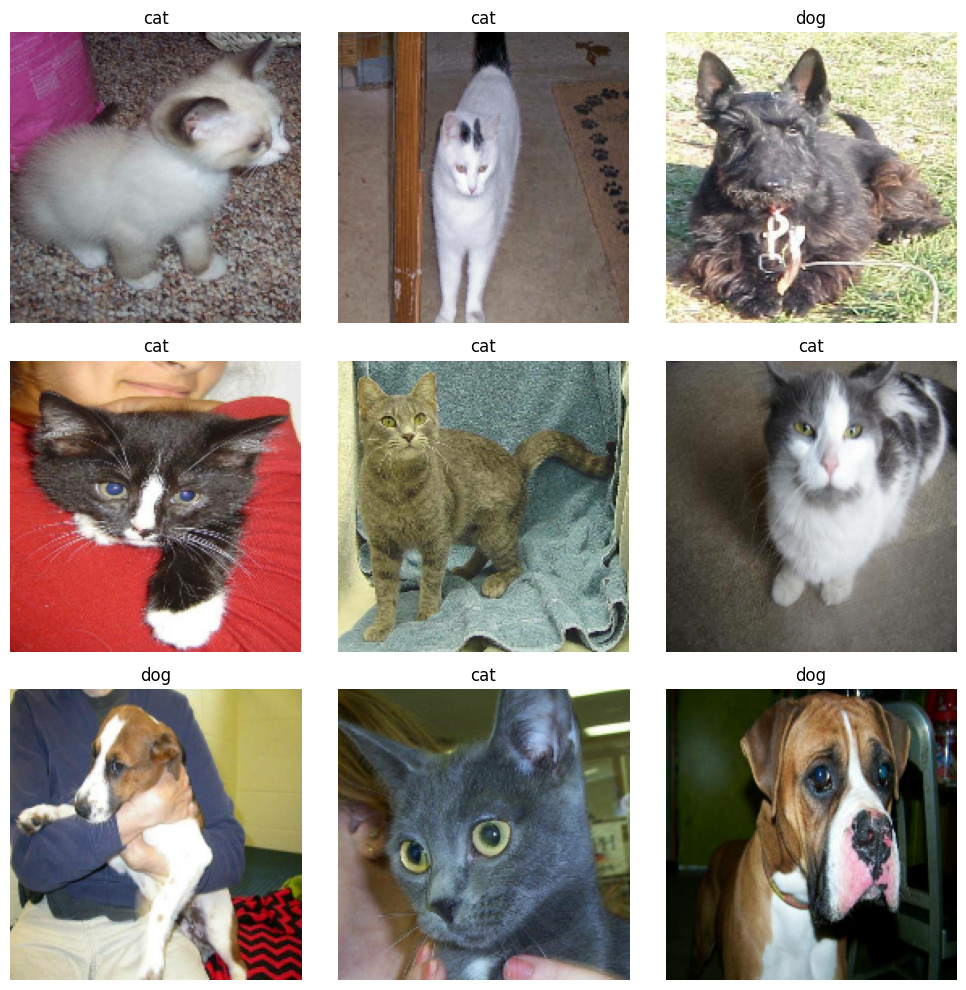

In [10]:
# Parte 3 - Exploracion de datos
if "train_ds" not in globals():
    raise RuntimeError("Ejecute primero la Parte 2 para crear train_ds y val_ds.")

image_batch, label_batch = next(iter(train_ds))

print(f"Tipo de image_batch: {type(image_batch)}")
print(f"Shape de image_batch: {image_batch.shape}")
print(f"Dtype de image_batch: {image_batch.dtype}")
print(f"Rango de pixeles: [{tf.reduce_min(image_batch).numpy():.1f}, {tf.reduce_max(image_batch).numpy():.1f}]")
print(f"Tipo de label_batch: {type(label_batch)}")
print(f"Shape de label_batch: {label_batch.shape}")
print(f"Dtype de label_batch: {label_batch.dtype}")
print(f"Primeras etiquetas: {label_batch[:10].numpy().reshape(-1)}")
print(f"Clases: {class_names}")

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    label_index = int(label_batch[i].numpy().item())
    plt.title(class_names[label_index])
    plt.axis("off")
plt.tight_layout()
plt.show()

#### Respuesta Parte 3

Los datos quedan almacenados como un `tf.data.Dataset`. Cada elemento del dataset es un batch con dos tensores: uno para las imágenes y otro para las etiquetas.

Las imágenes tienen forma `(batch_size, 180, 180, 3)`: `32` imágenes por batch, tamaño `180 x 180` y `3` canales de color RGB. Las etiquetas tienen forma `(batch_size, 1)` porque se usó `label_mode="binary"`, entonces cada imagen tiene etiqueta `0` o `1` según la clase.

El formato es adecuado para entrenar una red neuronal convolucional. Lo único a tener en cuenta es que los píxeles vienen en escala `[0, 255]`, por lo que más adelante conviene normalizarlos, por ejemplo con una capa `Rescaling(1./255)` dentro del modelo.

## Parte 4 - Aumento de datos

**4a)** Siguiendo con el ejemplo de keras, realizar aumento de datos a la primer imagen del dataset y mostrar los resultados.      
**4b)** Además de las opciones que se muestan el ejemplo ¿Qué otras opciones de aumento de datos brinda Keras? Muestre alguna que no aparezca en el ejemplo.      
**4c)** Asegúrese de entender por qué en algún caso puede tener sentido realizar el aumento de datos en el modelo y en otros sobre el dataset.  

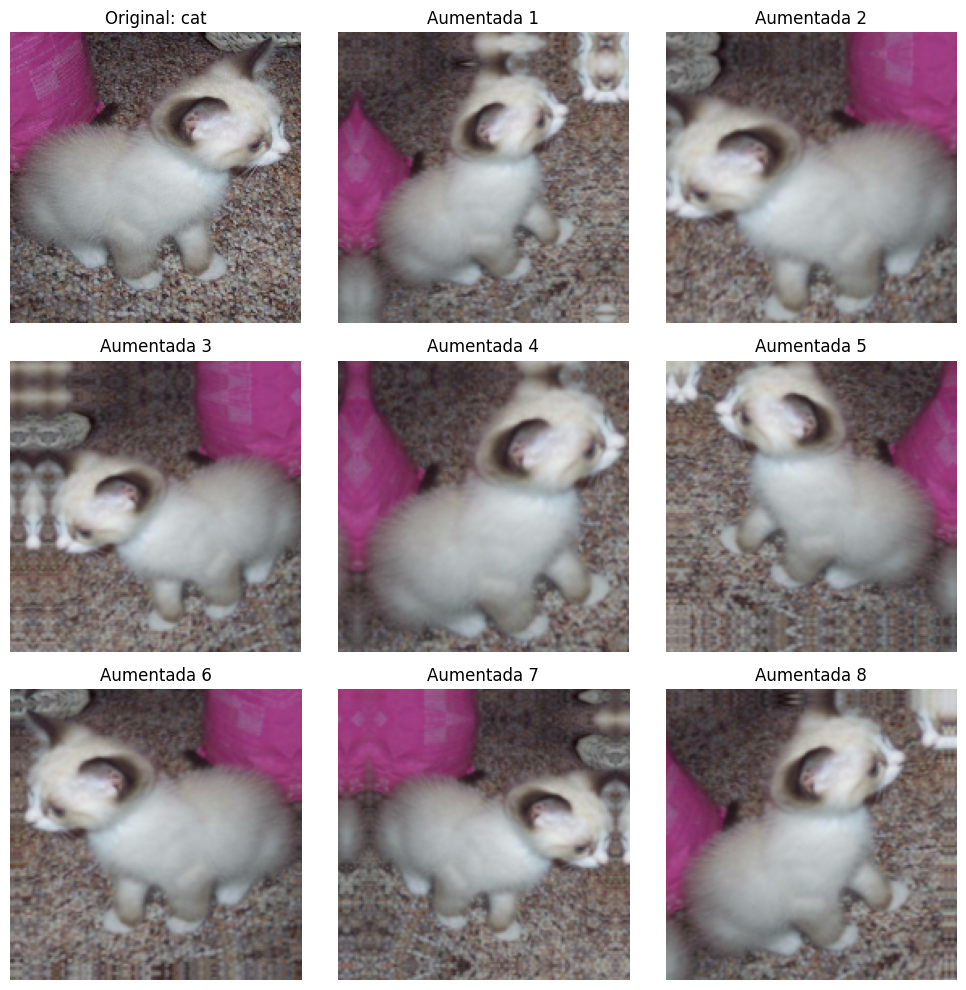

In [11]:
# 4a. Aumento de datos sobre la primera imagen del dataset
if "train_ds" not in globals():
    raise RuntimeError("Ejecute primero la Parte 2 para crear train_ds y val_ds.")

if "image_batch" not in globals() or "label_batch" not in globals():
    image_batch, label_batch = next(iter(train_ds))

first_image = image_batch[0]
first_label = int(label_batch[0].numpy().item())
first_class_name = class_names[first_label]

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    ],
    name="data_augmentation",
)

plt.figure(figsize=(10, 10))

ax = plt.subplot(3, 3, 1)
plt.imshow(first_image.numpy().astype("uint8"))
plt.title(f"Original: {first_class_name}")
plt.axis("off")

for i in range(8):
    augmented_image = data_augmentation(tf.expand_dims(first_image, axis=0), training=True)[0]
    ax = plt.subplot(3, 3, i + 2)
    plt.imshow(tf.clip_by_value(augmented_image, 0, 255).numpy().astype("uint8"))
    plt.title(f"Aumentada {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Respuesta 4a

La celda toma la primera imagen del dataset y genera varias versiones aumentadas aplicando transformaciones aleatorias: espejado horizontal, rotación, zoom y traslación.

Aunque la imagen cambie visualmente, la etiqueta no cambia. Si la imagen original era un gato, todas las versiones siguen siendo gato; si era un perro, siguen siendo perro. Esto permite mostrarle al modelo ejemplos más variados y ayuda a que aprenda patrones generales en vez de memorizar imágenes exactas.

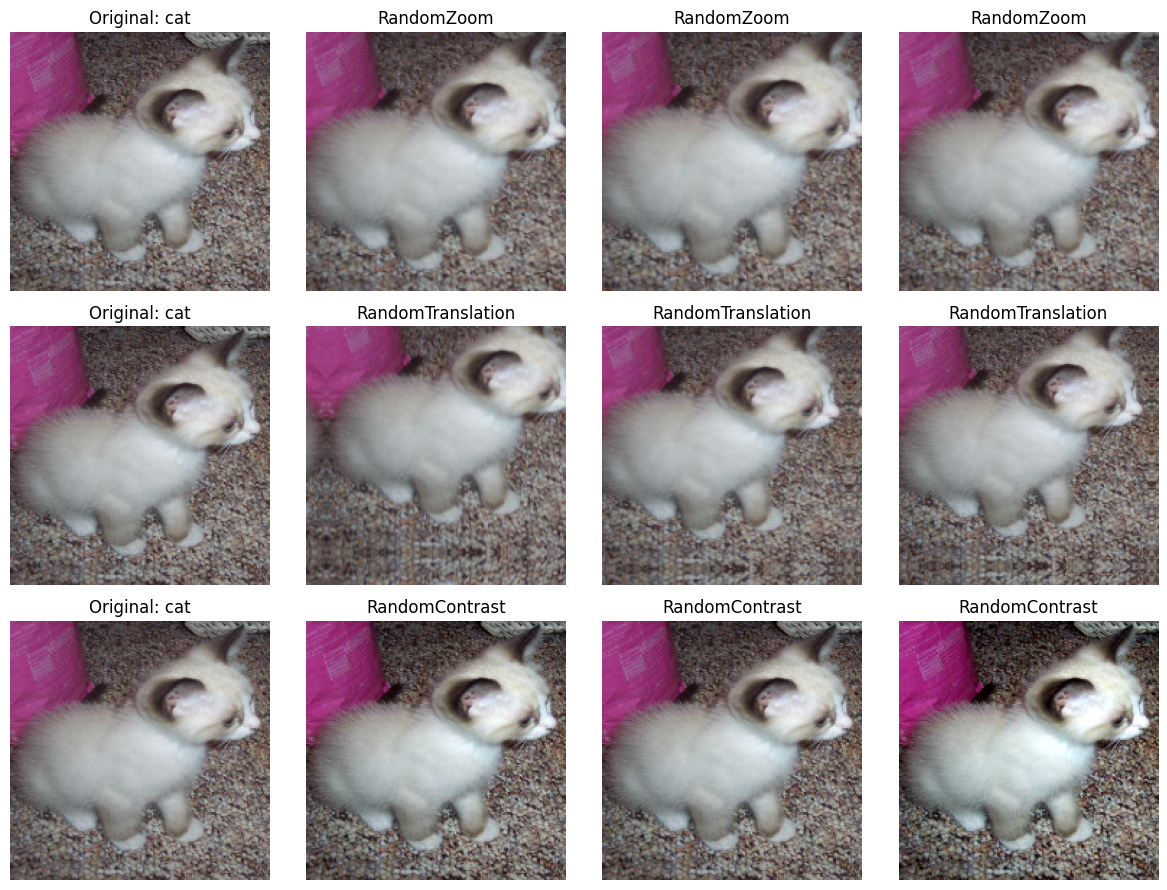

In [12]:
# 4b. Otras opciones de aumento de datos de Keras
if "first_image" not in globals():
    if "train_ds" not in globals():
        raise RuntimeError("Ejecute primero la Parte 2 para crear train_ds y val_ds.")
    image_batch, label_batch = next(iter(train_ds))
    first_image = image_batch[0]
    first_label = int(label_batch[0].numpy().item())
    first_class_name = class_names[first_label]

extra_augmentations = {
    "RandomZoom": layers.RandomZoom(0.25),
    "RandomTranslation": layers.RandomTranslation(height_factor=0.15, width_factor=0.15),
    "RandomContrast": layers.RandomContrast(0.4),
}

plt.figure(figsize=(12, 9))

plot_index = 1
for augmentation_name, augmentation_layer in extra_augmentations.items():
    ax = plt.subplot(len(extra_augmentations), 4, plot_index)
    plt.imshow(first_image.numpy().astype("uint8"))
    plt.title(f"Original: {first_class_name}")
    plt.axis("off")
    plot_index += 1

    for _ in range(3):
        augmented_image = augmentation_layer(tf.expand_dims(first_image, axis=0), training=True)[0]
        ax = plt.subplot(len(extra_augmentations), 4, plot_index)
        plt.imshow(tf.clip_by_value(augmented_image, 0, 255).numpy().astype("uint8"))
        plt.title(augmentation_name)
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

#### Respuesta 4b

Además de `RandomFlip` y `RandomRotation`, Keras brinda otras capas de aumento de datos. En la celda se muestran tres que son útiles para este problema:

- `RandomZoom`: simula que el animal aparece más cerca o más lejos.
- `RandomTranslation`: desplaza la imagen, útil si el animal no está perfectamente centrado.
- `RandomContrast`: cambia el contraste, útil para variar condiciones de iluminación o calidad de imagen.

Estas transformaciones son razonables porque no cambian la clase: una imagen aumentada de un gato sigue siendo gato y una de un perro sigue siendo perro.

#### Respuesta 4c

El aumento de datos puede aplicarse **dentro del modelo** o directamente sobre el **dataset**.

Si se agrega dentro del modelo mediante capas como `RandomFlip` o `RandomRotation`, las transformaciones se aplican automáticamente durante el entrenamiento, pero se desactivan durante validación, test e inferencia. Además, el aumento queda guardado como parte del modelo, lo que facilita reproducir el mismo preprocesamiento. Esta es una opción cómoda y segura para este taller.

Si se aplica sobre el dataset usando `train_ds.map(...)`, el procesamiento ocurre en el pipeline de datos. Esto permite controlar mejor el orden de las operaciones y aprovechar herramientas como `prefetch`, pero hay que asegurarse de aplicarlo solamente al conjunto de entrenamiento y no a validación o test.

En ambos casos las transformaciones se generan al vuelo, por lo que no es necesario guardar nuevas imágenes en disco. Para este problema conviene incorporarlas dentro del modelo, porque mantiene el pipeline más simple y evita aumentar accidentalmente los datos de validación.

## Parte 5 - Entrenando con aumento de datos en el modelo

Copie el modelo del ejemplo y entrene durante 10 épocas utilizando dicho modelo.

**5a)** Asegúrese que entiende cómo fue construída la red y cada uno de los bloques que se utilizan      
**5b)** Modifique la salida de la red para que la salida tenga *num_classes* unidades independientemente de cuál sea el número de clases.         
**5c)** Entrene la red durante 10 épocas          

In [13]:
# Parte 5 - Modelo con aumento de datos integrado
if "num_classes" not in globals():
    raise RuntimeError("Ejecute primero la Parte 2 para definir num_classes.")

input_shape = img_size + (3,)

part5_data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ],
    name="part5_data_augmentation",
)

def make_part5_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = part5_data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])
        previous_block_activation = x

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="part5_cats_vs_dogs")

keras.utils.set_random_seed(seed)
part5_model = make_part5_model(input_shape=input_shape, num_classes=num_classes)
part5_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

part5_model.summary()

Model: "part5_cats_vs_dogs"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ part5_data_augment… │ (None, 180, 180,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 180, 180,  │          0 │ part5_data_augme… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 90, 90,    │      3,584 │ rescaling[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 90, 90,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 90, 90,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 90, 90,    │          0 │ activation[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 90, 90,    │     34,176 │ activation_1[0][… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 90, 90,    │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 90, 90,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 90, 90,    │     68,096 │ activation_2[0][… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 90, 90,    │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 45, 45,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 45, 45,    │     33,024 │ activation[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 45, 45,    │          0 │ max_pooling2d[0]… │
│                     │ 256)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 45, 45,    │          0 │ add[0][0]         │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 45, 45,    │    133,888 │ activation_3[0][

 Total params: 2,732,090 (10.42 MB)

 Trainable params: 2,723,802 (10.39 MB)

 Non-trainable params: 8,288 (32.38 KB)

#### Respuesta 5a y 5b

El modelo sigue la estructura del ejemplo de Keras para clasificación de imágenes desde cero. Primero aplica aumento de datos dentro del modelo, por lo que esas transformaciones se usan durante entrenamiento pero no durante validación o inferencia. Después normaliza los píxeles con `Rescaling(1./255)`, pasando del rango `[0, 255]` a `[0, 1]`.

La red luego usa bloques convolucionales con `SeparableConv2D`, `BatchNormalization`, activación `relu`, `MaxPooling2D` y conexiones residuales. Las convoluciones extraen patrones visuales locales; el pooling reduce el tamaño espacial; Batch Normalization estabiliza el entrenamiento; y las conexiones residuales ayudan a entrenar redes más profundas.

Al final se usa `GlobalAveragePooling2D` para resumir los mapas de activación, `Dropout` para reducir sobreajuste y una capa de salida `Dense(num_classes, activation="softmax")`. Esta última parte responde a 5b que la salida no queda fijada manualmente en 2 unidades, sino que depende de la variable `num_classes`.

In [14]:
# Parte 5c - Entrenamiento durante 10 epocas
if "part5_model" not in globals():
    raise RuntimeError("Ejecute primero la celda donde se define part5_model.")

# Como en Parte 2 usamos label_mode="binary", las etiquetas vienen con forma (batch, 1).
# Para sparse_categorical_crossentropy las pasamos a forma (batch,) y tipo entero.
def prepare_sparse_labels(images, labels):
    labels = tf.cast(tf.reshape(labels, [-1]), tf.int32)
    return images, labels

train_ds_part5 = train_ds.map(prepare_sparse_labels, num_parallel_calls=AUTOTUNE)
val_ds_part5 = val_ds.map(prepare_sparse_labels, num_parallel_calls=AUTOTUNE)

part5_history = part5_model.fit(
    train_ds_part5,
    epochs=10,
    validation_data=val_ds_part5,
)

Epoch 1/10


I0000 00:00:1781094947.743544    4325 cuda_dnn.cc:461] Loaded cuDNN version 92300
W0000 00:00:1781094951.358512    4325 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.63GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1781094951.861437    4325 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.36GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1781094952.141095    4325 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.08GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1781094952.943278    4325 bfc_allocator.cc:311] 

625/625 ━━━━━━━━━━━━━━━━━━━━ 251s 383ms/step - accuracy: 0.6162 - loss: 0.6719 - val_accuracy: 0.5022 - val_loss: 1.3530
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 242s 387ms/step - accuracy: 0.7025 - loss: 0.5820 - val_accuracy: 0.7288 - val_loss: 0.5320
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 251s 402ms/step - accuracy: 0.7717 - loss: 0.4868 - val_accuracy: 0.7116 - val_loss: 0.6429
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 246s 393ms/step - accuracy: 0.8105 - loss: 0.4188 - val_accuracy: 0.8246 - val_loss: 0.3812
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 247s 395ms/step - accuracy: 0.8398 - loss: 0.3637 - val_accuracy: 0.8692 - val_loss: 0.3032
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 250s 400ms/step - accuracy: 0.8624 - loss: 0.3224 - val_accuracy: 0.7058 - val_loss: 0.7994
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 250s 400ms/step - accuracy: 0.8831 - loss: 0.2734 - val_accuracy: 0.9120 - val_loss: 0.2185
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 249s 399ms/step - accuracy: 0.8961 - loss: 0.24

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
1,0.61625,0.671904,0.5022,1.352994
2,0.70255,0.582015,0.7288,0.531964
3,0.77175,0.486777,0.7116,0.642950
4,0.81050,0.418771,0.8246,0.381226
5,0.83980,0.363712,0.8692,0.303197
6,0.86240,0.322378,0.7058,0.799434
7,0.88310,0.273380,0.9120,0.218529
8,0.89610,0.246964,0.9184,0.211732
9,0.90525,0.223160,0.9238,0.195434


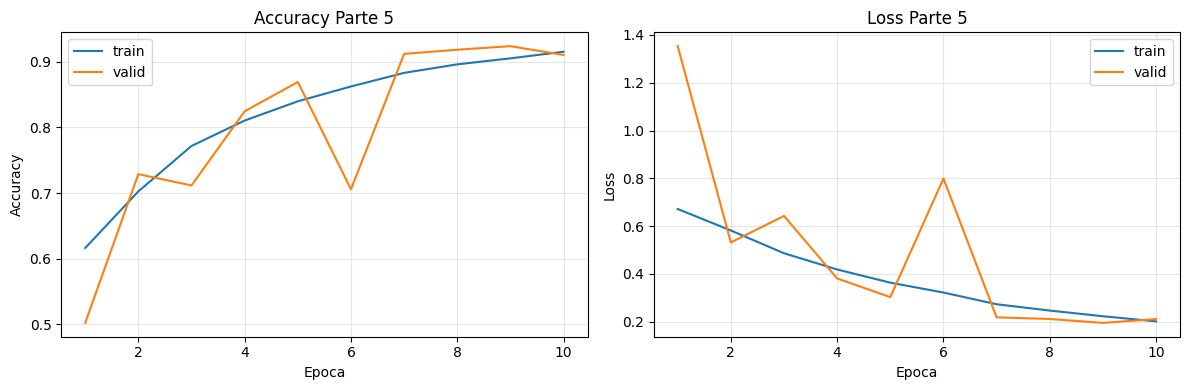

In [15]:
# Tabla y curvas del entrenamiento del modelo original
import pandas as pd

if "part5_history" not in globals():
    raise RuntimeError("Ejecute primero la celda de entrenamiento de la Parte 5.")

part5_results_df = pd.DataFrame(part5_history.history)
part5_results_df.index = part5_results_df.index + 1
part5_results_df.index.name = "epoch"
display(part5_results_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(part5_results_df.index, part5_results_df["accuracy"], label="train")
axes[0].plot(part5_results_df.index, part5_results_df["val_accuracy"], label="valid")
axes[0].set_title("Accuracy Parte 5")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(part5_results_df.index, part5_results_df["loss"], label="train")
axes[1].plot(part5_results_df.index, part5_results_df["val_loss"], label="valid")
axes[1].set_title("Loss Parte 5")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Observación sobre el entrenamiento del modelo original

Se entrenó durante 10 épocas la arquitectura original propuesta en el ejemplo de Keras. Este modelo integra aumento de datos, reescalado de los píxeles, convoluciones separables, Batch Normalization, activaciones ReLU, MaxPooling, conexiones residuales, Global Average Pooling, Dropout y una salida softmax dependiente de `num_classes`.

No se trata de una CNN pequeña: utiliza bloques con `256`, `512` y `728` filtros, seguidos por una convolución separable de `1024` filtros. En total tiene aproximadamente 2,73 millones de parámetros. Además, durante el entrenamiento deben conservarse en memoria las activaciones y los gradientes de mapas de características grandes.

El proceso resultó largo, cada época demoró aproximadamente 6 minutos y las 10 épocas requirieron cerca de 64 minutos.

La salida anterior corresponde al entrenamiento completo de este modelo. La mejor época según los datos de validación fue la época 9, con una exactitud de validación de **0,9238** y una pérdida de validación de **0,1954**. En la época 10 la exactitud de entrenamiento llegó a **0,9153**, mientras que la exactitud de validación bajó levemente a **0,9104**, por lo que continuar entrenando no necesariamente implicaba una mejora en la generalización.

Aunque el modelo original obtuvo buenos resultados, su tiempo de entrenamiento dificulta realizar varias pruebas y comparar configuraciones. Por esto para los siguientes experimentos contruyo una versión más compacta que conserve el enfoque de —CNN, aumento de datos, normalización, pooling y regularización— pero reduzca el costo.

In [ ]:
# Parte 5 - Version compacta del modelo
if "num_classes" not in globals():
    raise RuntimeError("Ejecute primero la Parte 2 para definir num_classes.")

# Libera los recursos del modelo grande antes de construir la version compacta.
keras.backend.clear_session()

compact_data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
    ],
    name="compact_data_augmentation",
)

def make_compact_part5_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = compact_data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    for filters in [64, 128, 256]:
        x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="part5_compact_cats_vs_dogs")

keras.utils.set_random_seed(seed)
part5_compact_model = make_compact_part5_model(
    input_shape=img_size + (3,),
    num_classes=num_classes,
)
part5_compact_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

part5_compact_model.summary()

Model: "part5_compact_cats_vs_dogs"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_data_augmentation       │ (None, 180, 180, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 90, 90, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 90, 90, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 90, 90, 64)     │         2,336 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 45, 45, 128)    │         8,768 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 22, 22, 256)    │        33,920 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 48,322 (188.76 KB)

 Trainable params: 47,362 (185.01 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.8188 - loss: 0.3962 - val_accuracy: 0.8110 - val_loss: 0.3987
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.8281 - loss: 0.3829 - val_accuracy: 0.8590 - val_loss: 0.3383
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.8378 - loss: 0.3670 - val_accuracy: 0.8344 - val_loss: 0.3605
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.8422 - loss: 0.3599 - val_accuracy: 0.7490 - val_loss: 0.5545
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 81ms/step - accuracy: 0.8490 - loss: 0.3504 - val_accuracy: 0.7568 - val_loss: 0.5337
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.8548 - loss: 0.3361 - val_accuracy: 0.8336 - val_loss: 0.3696
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.8612 - loss: 0.3209 - val_accuracy: 0.7656 - val_loss: 0.4992
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.8661 - loss: 0.3119 - 

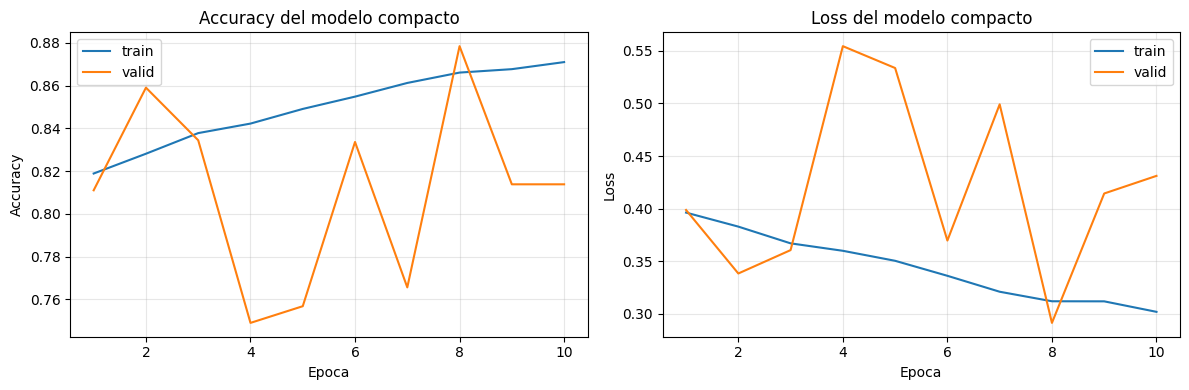

In [15]:
# Entrenamiento de la version compacta durante 10 epocas
if "part5_compact_model" not in globals():
    raise RuntimeError("Ejecute primero la celda del modelo compacto.")

def prepare_compact_labels(images, labels):
    labels = tf.cast(tf.reshape(labels, [-1]), tf.int32)
    return images, labels

train_ds_compact = train_ds.map(
    prepare_compact_labels,
    num_parallel_calls=AUTOTUNE,
).prefetch(AUTOTUNE)
val_ds_compact = val_ds.map(
    prepare_compact_labels,
    num_parallel_calls=AUTOTUNE,
).prefetch(AUTOTUNE)

part5_compact_history = part5_compact_model.fit(
    train_ds_compact,
    epochs=10,
    validation_data=val_ds_compact,
)

compact_metrics = part5_compact_history.history
compact_epochs = range(1, len(compact_metrics["accuracy"]) + 1)

print(f"Mejor accuracy de validacion: {max(compact_metrics['val_accuracy']):.4f}")
print(f"Menor loss de validacion: {min(compact_metrics['val_loss']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(compact_epochs, compact_metrics["accuracy"], label="train")
axes[0].plot(compact_epochs, compact_metrics["val_accuracy"], label="valid")
axes[0].set_title("Accuracy del modelo compacto")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(compact_epochs, compact_metrics["loss"], label="train")
axes[1].plot(compact_epochs, compact_metrics["val_loss"], label="valid")
axes[1].set_title("Loss del modelo compacto")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Observación sobre el modelo compacto

La versión compacta redujo el modelo de aproximadamente 2,73 millones de parámetros a 48.322 parámetros y reducir el tiempo por época. En la segunda corrida alcanzó su mejor resultado en la época 8, con una exactitud de validación de **0,8784** y una pérdida de validación de **0,2913**.

Después de esa época, la exactitud de entrenamiento continuó aumentando, pero el rendimiento de validación empeoró. Esto indica que seguir entrenando no estaba mejorando la capacidad de generalización del modelo.

Por eso, a continuación se realiza un entrenamiento nuevo desde cero con `EarlyStopping`. Este callback detiene el entrenamiento cuando `val_loss` deja de mejorar y recupera los pesos correspondientes a la mejor época, en lugar de conservar los de la última.

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - accuracy: 0.6266 - loss: 0.6591 - val_accuracy: 0.6156 - val_loss: 0.6570
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.7013 - loss: 0.5774 - val_accuracy: 0.7196 - val_loss: 0.5530
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7218 - loss: 0.5487 - val_accuracy: 0.5498 - val_loss: 0.9173
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.7423 - loss: 0.5253 - val_accuracy: 0.7530 - val_loss: 0.5166
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.7558 - loss: 0.5040 - val_accuracy: 0.7730 - val_loss: 0.4808
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.7742 - loss: 0.4786 - val_accuracy: 0.7880 - val_loss: 0.4588
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.7848 - loss: 0.4603 - val_accuracy: 0.7370 - val_loss: 0.5376
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - accuracy: 0.7975 - loss: 0.4367

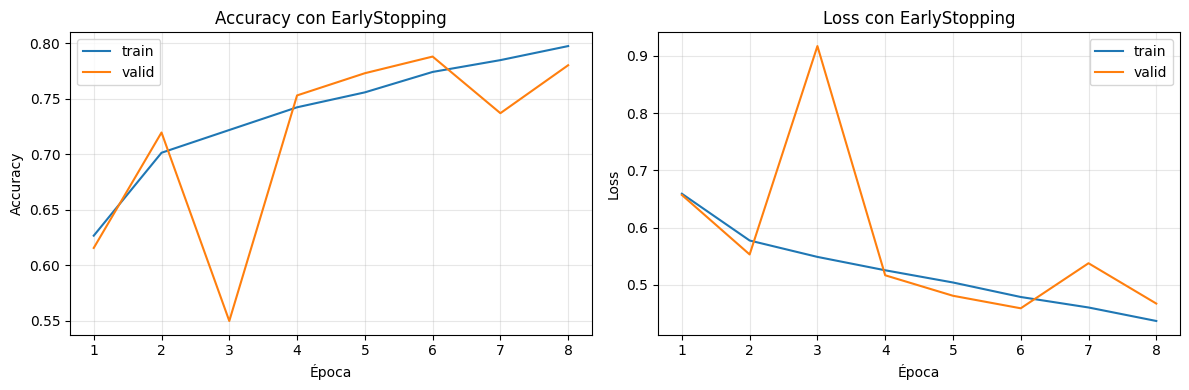

In [19]:
# Nuevo entrenamiento del modelo compacto con EarlyStopping
if "make_compact_part5_model" not in globals():
    raise RuntimeError("Ejecute primero la celda que define el modelo compacto.")

# Se crea un modelo nuevo para comenzar el experimento desde pesos iniciales.
part5_compact_early_model = make_compact_part5_model(
    input_shape=(180, 180, 3),
    num_classes=num_classes,
)
part5_compact_early_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

compact_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=2,
    restore_best_weights=True,
    verbose=1,
)

part5_compact_early_history = part5_compact_early_model.fit(
    train_ds_compact,
    epochs=10,
    validation_data=val_ds_compact,
    callbacks=[compact_early_stopping],
)

early_metrics = part5_compact_early_history.history
early_epochs = range(1, len(early_metrics["accuracy"]) + 1)
best_early_epoch = early_metrics["val_loss"].index(
    min(early_metrics["val_loss"])
) + 1

print(f"Épocas ejecutadas: {len(early_metrics['loss'])}")
print(f"Mejor época según val_loss: {best_early_epoch}")
print(f"Mejor accuracy de validación: {max(early_metrics['val_accuracy']):.4f}")
print(f"Menor loss de validación: {min(early_metrics['val_loss']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(early_epochs, early_metrics["accuracy"], label="train")
axes[0].plot(early_epochs, early_metrics["val_accuracy"], label="valid")
axes[0].set_title("Accuracy con EarlyStopping")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(early_epochs, early_metrics["loss"], label="train")
axes[1].plot(early_epochs, early_metrics["val_loss"], label="valid")
axes[1].set_title("Loss con EarlyStopping")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Observación final

En esta parte se entrenó primero la arquitectura original del ejemplo de Keras, incorporando aumento de datos, normalización, convoluciones separables, Batch Normalization, conexiones residuales, pooling y regularización. Con aproximadamente 2,73 millones de parámetros, este modelo obtuvo el mejor rendimiento de los experimentos, alcanzó una exactitud de validación de **0,9238** y una pérdida de **0,1954** en la época 9. Sin embargo, el entrenamiento completo fue costoso y demoró más de 40 minutos, lo que dificultaba realizar nuevas pruebas.

La reducción disminuyó notablemente el tiempo por época, aunque también redujo el mejor resultado de validación a **0,8784**. Esto muestra el compromiso existente entre capacidad del modelo, costo computacional y rendimiento.

Finalmente, se incorporó `EarlyStopping` para controlar el entrenamiento del modelo compacto. En esa corrida se detuvo en la época 8 y restauró los pesos de la época 6, evitando conservar épocas posteriores que no mejoraban `val_loss`. El resultado fue inferior al de otras.

En conclusión, el modelo original ofreció la mejor capacidad de clasificación, mientras que el modelo compacto resultó más práctico para probar configuraciones.

## Parte 6 - Utilizando Modelos Preentrenados

En esta parte en vez de entrenar un modelo desde cero vamos a utilizar un modelo preentrenado en otro problema y adaptarlo al de clasificar entre perros y gatos. Se evaluarán dos modelos: Resnet50 y Xception.

**6a)** Levantar ambos modelos con los pesos preentrenados con la base *Imagenet*. Ver un ejemplo en la sección *Using Pretrained Models from Keras* del *Capíítulo 14* del libro del curso.  
**6b)** Adaptar el ejemplo del libro para mostrar, para cada una de los modelos cargados, cuáles son las *top3* clases de un *batch* de imágenes del dataset de entrenamiento. ¿Qué observa?  

In [20]:
# Parte 6a - Carga de modelos preentrenados con ImageNet
resnet50_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=True,
)

xception_model = keras.applications.Xception(
    weights="imagenet",
    include_top=True,
)

print(
    f"ResNet50: {resnet50_model.count_params():,} parámetros, "
    f"entrada {resnet50_model.input_shape}, salida {resnet50_model.output_shape}"
)
print(
    f"Xception: {xception_model.count_params():,} parámetros, "
    f"entrada {xception_model.input_shape}, salida {xception_model.output_shape}"
)

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 288s 3us/step
91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 269s 3us/step
ResNet50: 25,636,712 parámetros, entrada (None, 224, 224, 3), salida (None, 1000)
Xception: 22,910,480 parámetros, entrada (None, 299, 299, 3), salida (None, 1000)


35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Imagen 1 - Etiqueta real: cat
  ResNet50:
    studio_couch: 14.30%
    refrigerator: 7.31%
    bookcase: 5.75%
  Xception:
    Egyptian_cat: 14.57%
    Scotch_terrier: 3.53%
    schipperke: 2.98%

Imagen 2 - Etiqueta real: cat
  ResNet50:
    Chihuahua: 66.58%
    wombat: 6.37%
    tabby: 4.61%
  Xception:
    Chihuahua: 6.40%
    tabby: 4.55%
    Egyptian_cat: 3.28%

Imagen 3 - Etiqueta real: dog
  ResNet50:
    English_setter: 34.55%
    kuvasz: 15.07%
    borzoi: 13.87%
  Xception:
    English_setter: 42.31%
    kuvasz: 20.79%
    borzoi: 8.53%

Imagen 4 - Etiqueta real: dog
  ResNet50:
    toy_terrier: 72.03%
    Chihuahua: 15.27%
    miniature_pinscher: 8.47%
  Xception:
    toy_terrier: 71.06%
    basenji: 5.34%
    Chihuahua: 4.97%



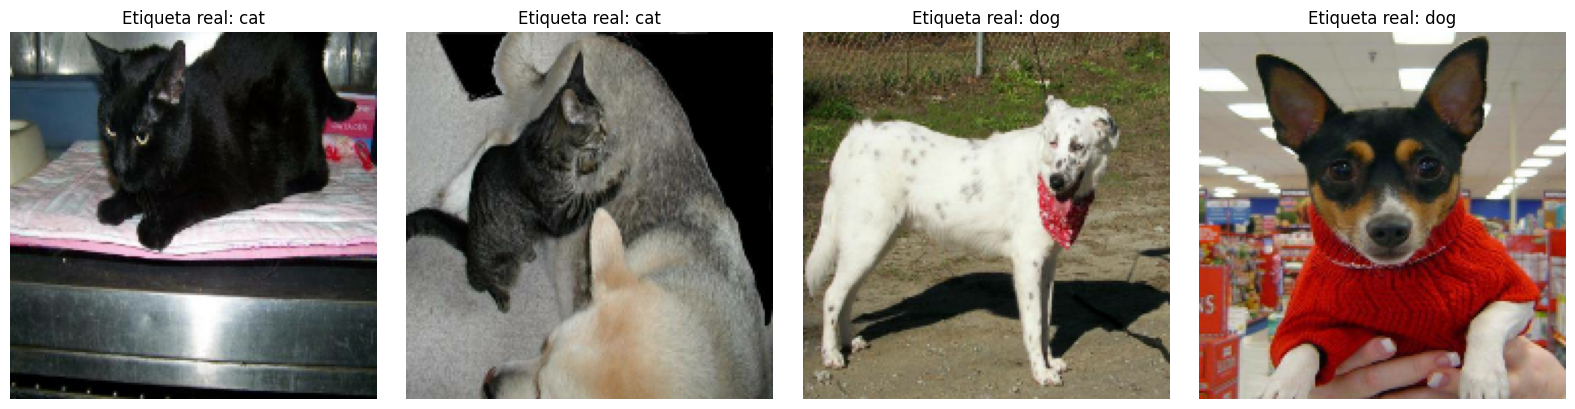

In [21]:
# Parte 6b - Top 3 de ImageNet para imágenes del dataset
if "resnet50_model" not in globals() or "xception_model" not in globals():
    raise RuntimeError("Ejecute primero la Parte 6a para cargar ambos modelos.")

batch_images, batch_labels = next(iter(train_ds))
num_examples = min(4, int(batch_images.shape[0]))
sample_images = batch_images[:num_examples]
sample_labels = tf.cast(
    tf.reshape(batch_labels[:num_examples], [-1]),
    tf.int32,
)

# Cada modelo necesita su propio tamaño de entrada y preprocesamiento.
resnet_inputs = tf.image.resize(sample_images, (224, 224))
resnet_inputs = keras.applications.resnet50.preprocess_input(resnet_inputs)
resnet_predictions = resnet50_model(resnet_inputs, training=False).numpy()
resnet_top3 = keras.applications.resnet50.decode_predictions(
    resnet_predictions,
    top=3,
)

xception_inputs = tf.image.resize(sample_images, (299, 299))
xception_inputs = keras.applications.xception.preprocess_input(xception_inputs)
xception_predictions = xception_model(xception_inputs, training=False).numpy()
xception_top3 = keras.applications.xception.decode_predictions(
    xception_predictions,
    top=3,
)

fig, axes = plt.subplots(1, num_examples, figsize=(4 * num_examples, 4))
if num_examples == 1:
    axes = [axes]

for index, axis in enumerate(axes):
    real_class = class_names[int(sample_labels[index].numpy())]
    axis.imshow(tf.cast(sample_images[index], tf.uint8))
    axis.set_title(f"Etiqueta real: {real_class}")
    axis.axis("off")

    print(f"Imagen {index + 1} - Etiqueta real: {real_class}")
    print("  ResNet50:")
    for _, class_name, probability in resnet_top3[index]:
        print(f"    {class_name}: {probability:.2%}")

    print("  Xception:")
    for _, class_name, probability in xception_top3[index]:
        print(f"    {class_name}: {probability:.2%}")
    print()

plt.tight_layout()
plt.show()

#### Parte 6b

Los modelos no predicen directamente las clases generales `cat` y `dog`, sino categorías específicas de ImageNet, como razas de perros y tipos de gatos. En las imágenes de perros, ResNet50 y Xception obtuvieron predicciones similares y generalmente correctas. En las imágenes de gatos mostraron mayor incertidumbre y llegaron a confundirlos con perros pequeños u objetos del entorno. Esto indica que ambos modelos aprendieron características visuales reutilizables, aunque sus predicciones están condicionadas por las clases con las que fueron entrenados originalmente.

## Parte 7 - Visualización de filtros

En el caso del modelo *Resnet50* mostrar los filtros aprendidos en la primera capa de convolución. Explique con algún ejemplo por qué puede ser razonable utilizar estos mismos filtros en otro problema.

Capa: conv1_conv
Forma de los filtros: (7, 7, 3, 64)
Cantidad de filtros: 64


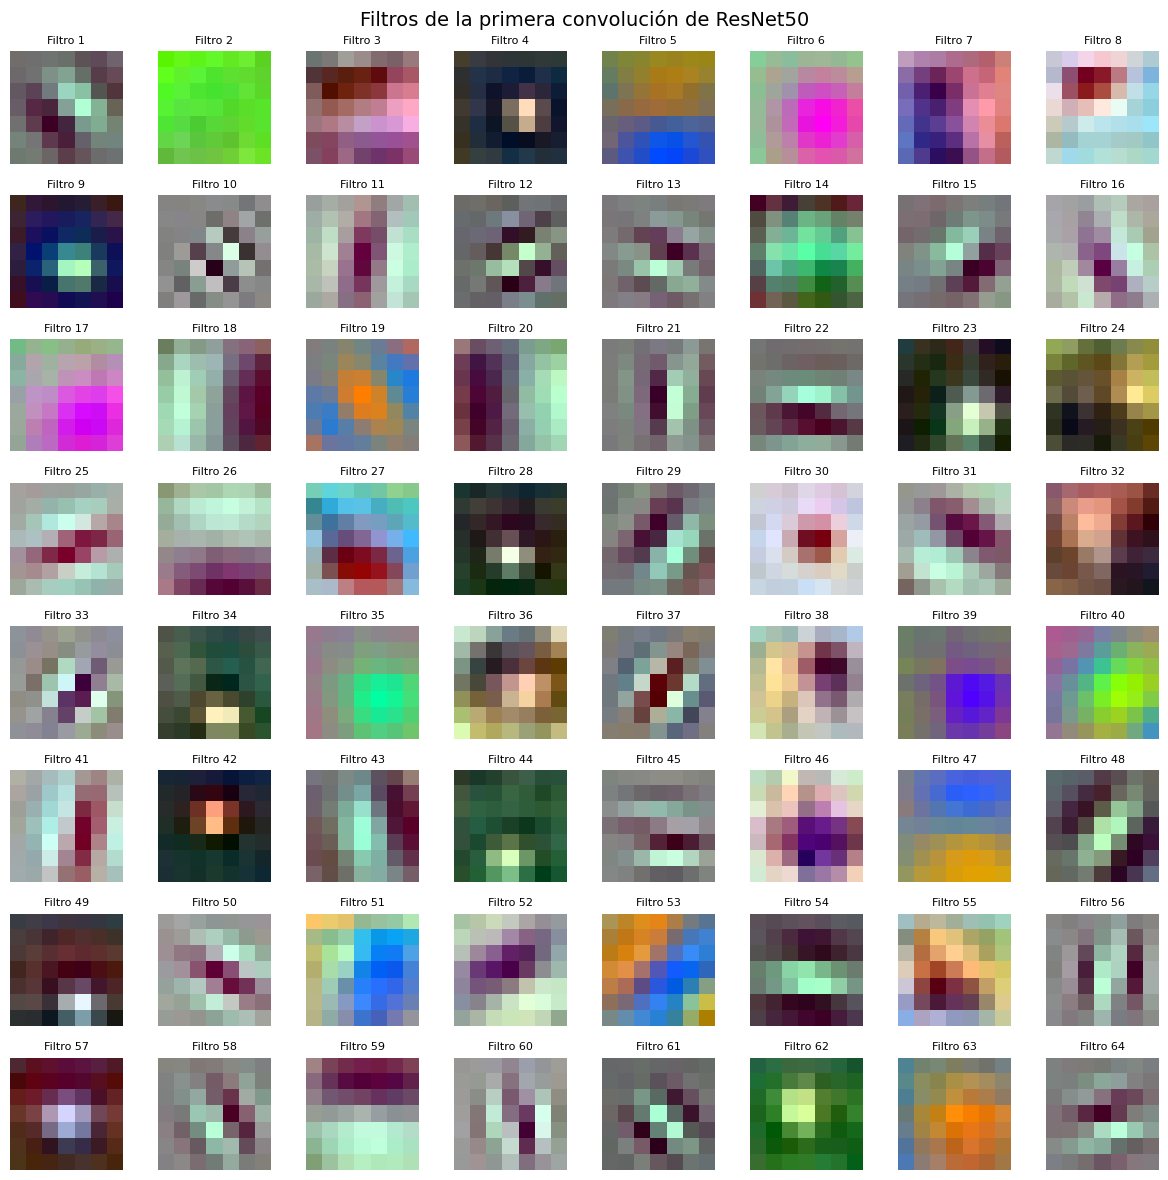

In [22]:
# Parte 7 - Filtros de la primera capa convolucional de ResNet50
if "resnet50_model" not in globals():
    raise RuntimeError("Ejecute primero la Parte 6a para cargar ResNet50.")

first_conv_layer = resnet50_model.get_layer("conv1_conv")
first_layer_filters = first_conv_layer.get_weights()[0]

print(f"Capa: {first_conv_layer.name}")
print(f"Forma de los filtros: {first_layer_filters.shape}")
print(f"Cantidad de filtros: {first_layer_filters.shape[-1]}")

num_filters = first_layer_filters.shape[-1]
fig, axes = plt.subplots(8, 8, figsize=(12, 12))

for filter_index, axis in enumerate(axes.flat):
    filter_image = first_layer_filters[:, :, :, filter_index]

    # Normalización independiente para hacer visible el patrón de cada filtro.
    filter_min = filter_image.min()
    filter_range = filter_image.max() - filter_min
    if filter_range > 0:
        filter_image = (filter_image - filter_min) / filter_range

    axis.imshow(filter_image, interpolation="nearest")
    axis.set_title(f"Filtro {filter_index + 1}", fontsize=8)
    axis.axis("off")

fig.suptitle("Filtros de la primera convolución de ResNet50", fontsize=14)
plt.tight_layout()
plt.show()

#### Parte 7

Es razonable reutilizar estos filtros porque esas características básicas aparecen en muchos problemas de visión y no dependen de una clase específica de ImageNet. Por ejemplo, un filtro que detecta un borde diagonal puede responder al contorno de la oreja de un perro en este problema, pero también al borde de un vehículo o de un objeto en otro conjunto de imágenes. Las capas posteriores son las que combinan estas características generales para formar representaciones más específicas de cada tarea.

## Parte 8 - Transferencia de aprendizaje

Tomando como referencia la sección *Pretrained Models for Transfer Learning*  del *Capíítulo 14* del libro y el ejemplo [Transfer Learning](https://keras.io/guides/transfer_learning/) de keras, realizar transferencia de aprendizaje utilizando ambos modelos. 

## Parte 9 - Grad Cam

Una vez que se entrena una red convolucional es muy útil entender en qué basa la red sus predicciones. Uno de los métodos propuestos en ese sentido es [GradCAM](https://arxiv.org/pdf/1610.02391.pdf). 

**9a)** ¿Para qué puede ser útil un método que explique los resultados obtenidos?     
**9b)** Adaptar el [ejemplo](https://keras.io/examples/vision/grad_cam/) de keras y mostrar sobre algunas imágenes de validación las predicciones realizadas y los mapas de activación superpuestos a la imagen. Para eso utilizar (o adaptar) las funciones `make_gradcam_heatmap()` y `save_and_display_gradcam()`.

## Parte 10 - Evauar con el conjunto de Test

Evaluar el modelo con que haya obtenido mejores resultados con el conjunto de validación con el conjunto de test. En este taller el foco no está puesto en optimizar los clasificadores, sin embargo verifique que los resultados obtenidos con el conjunto de test son del orden de los obtenidos con el conjunto de valdiación.